# Setup

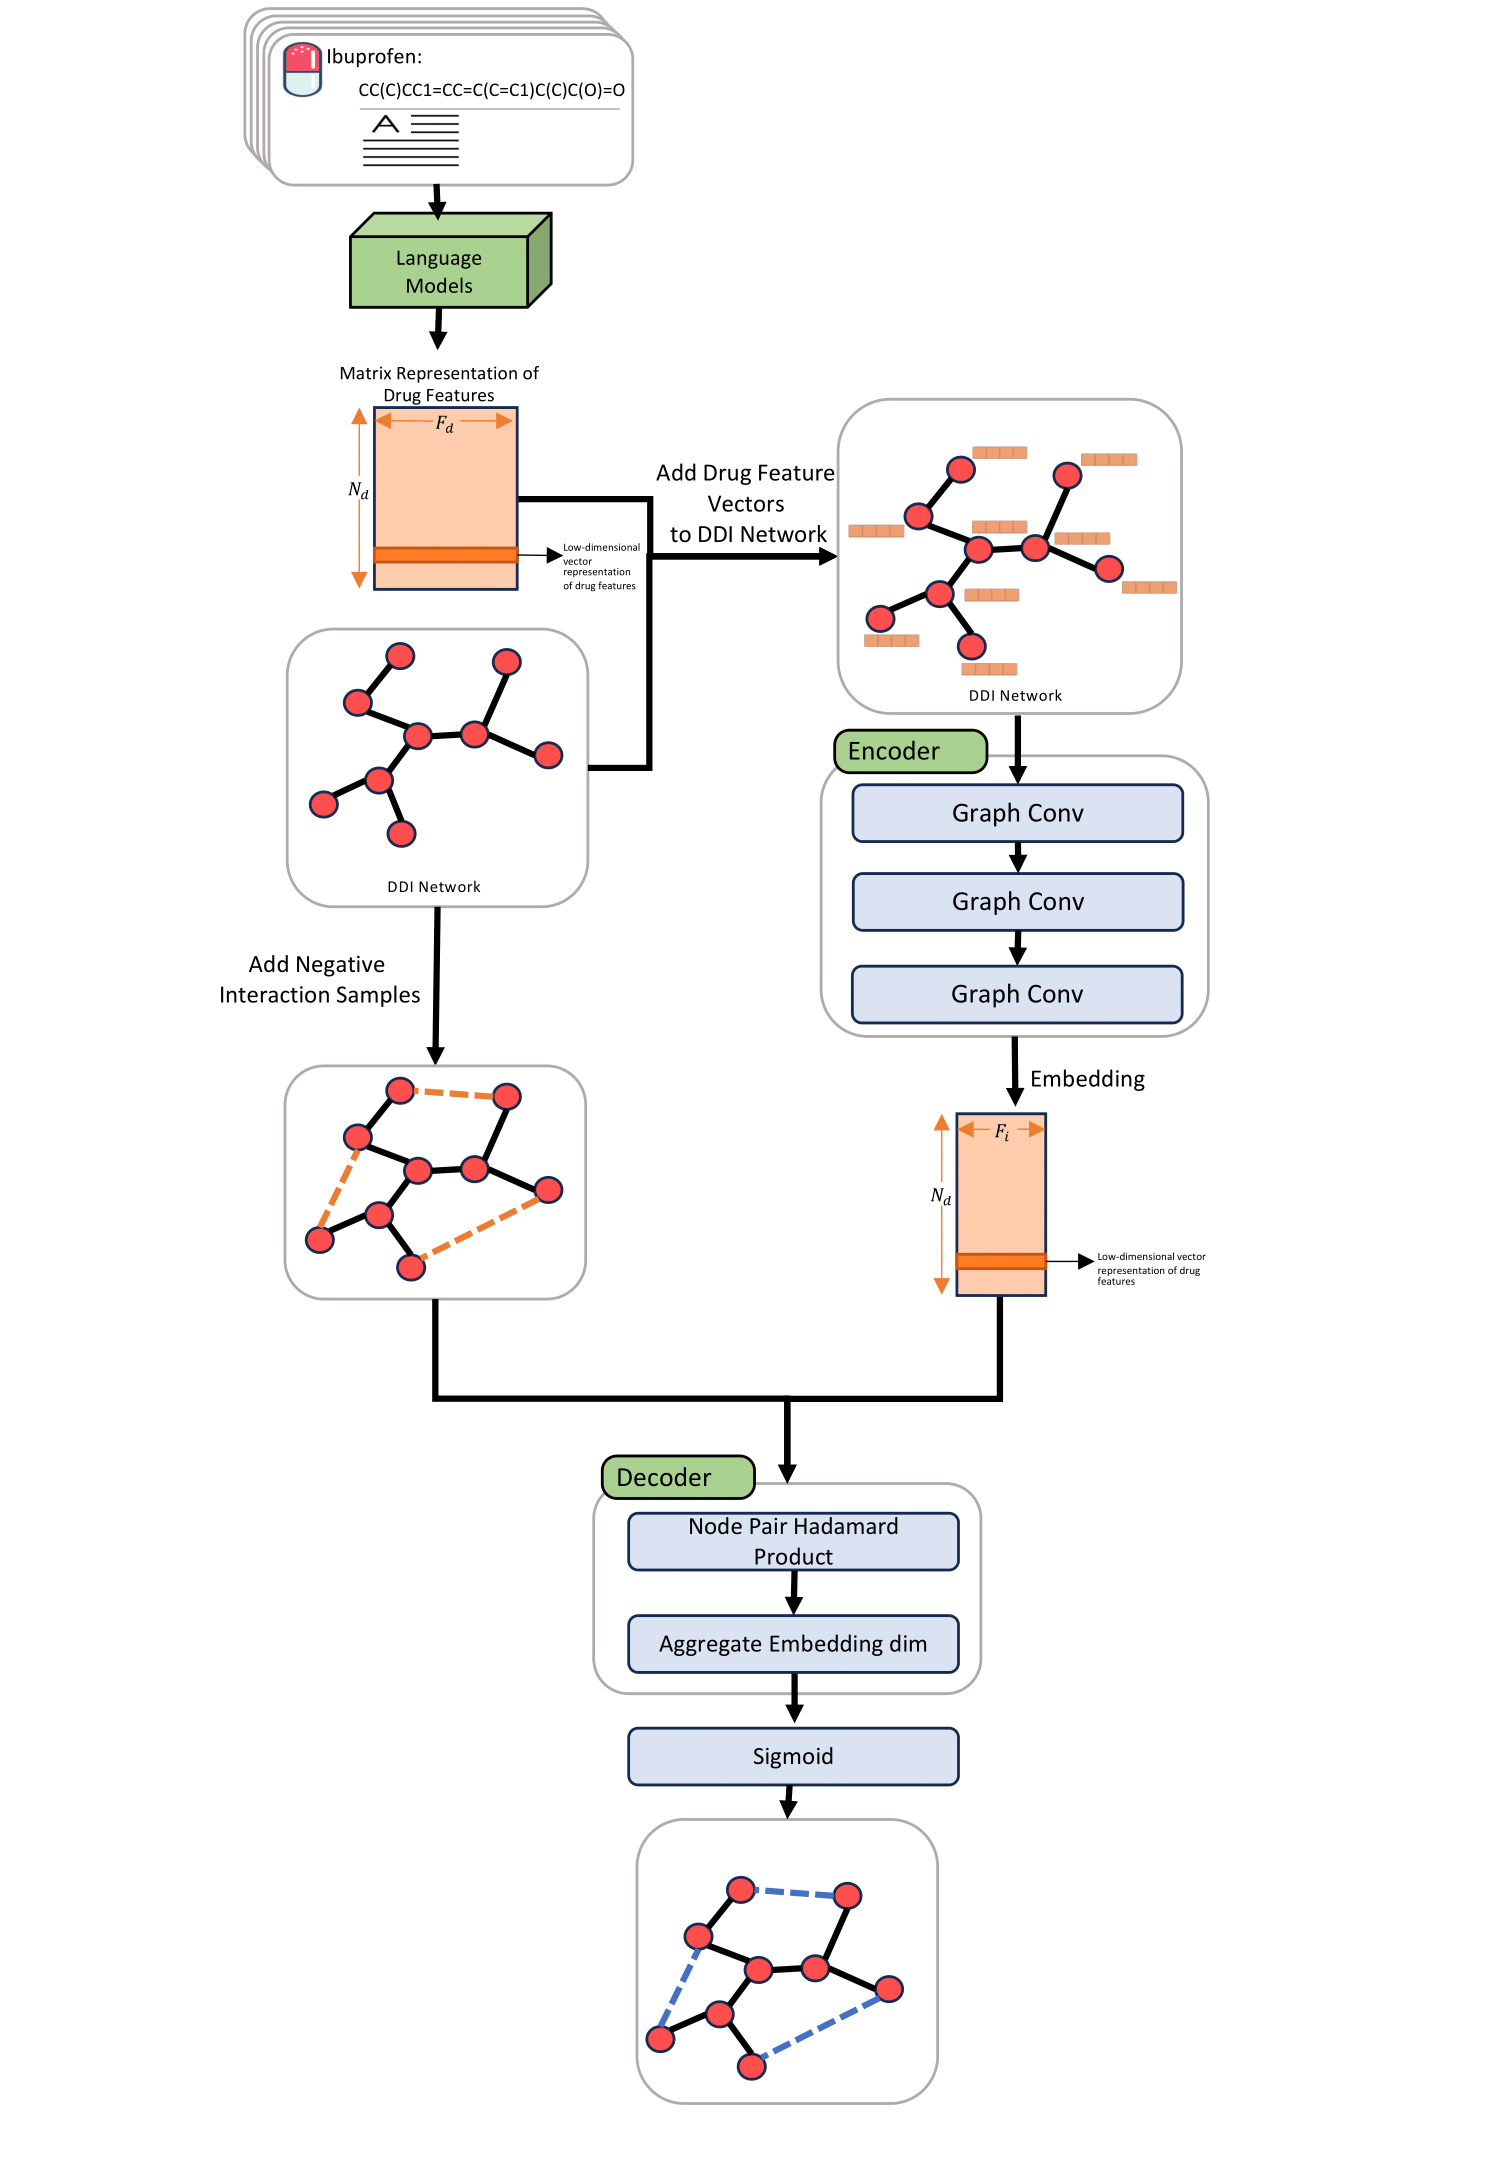

# Experiments

In [ ]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    PrecisionRecallDisplay,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    roc_curve,
## Analysis of trained model

import plotly.express as px
    upper = min(1.0, max_val + margin)
    if (upper - lower) < min_range:
        upper = min(1.0, lower + min_range)
        lower = max(0.0, upper - min_range)
    return lower, upper

# Prepare arrays for bars
roc_means = summary_df['ROC_AUC_mean'].to_numpy(dtype=float)
roc_err = summary_df['ROC_AUC_std'].to_numpy(dtype=float)
pr_means = summary_df['PR_AUC_mean'].to_numpy(dtype=float)
pr_err = summary_df['PR_AUC_std'].to_numpy(dtype=float)

roc_low, roc_hi = compute_ylim_with_offset(roc_means, roc_err)
pr_low, pr_hi = compute_ylim_with_offset(pr_means, pr_err)

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
(ax_roc_curve, ax_roc_bar), (ax_pr_curve, ax_pr_bar) = axes

# Top-left: ROC curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_roc_curve.plot(r['fpr'], r['tpr'], label=short, linewidth=2)
ax_roc_curve.plot([0,1],[0,1],'k--', alpha=0.25)
ax_roc_curve.set_title('ROC Curves')
ax_roc_curve.set_xlabel('False Positive Rate')
ax_roc_curve.set_ylabel('True Positive Rate')
ax_roc_curve.grid(alpha=0.4)
ax_roc_curve.legend(title='Setting', fontsize='small')

# Top-right: ROC AUC bar
bars_roc = ax_roc_bar.bar(indices, roc_means, yerr=roc_err, capsize=6, color=sns.color_palette('Blues', n_colors=len(labels)))
ax_roc_bar.set_xticks(indices)
ax_roc_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_roc_bar.set_ylim(roc_low, roc_hi)
ax_roc_bar.set_title('ROC AUC per Setting')
ax_roc_bar.set_ylabel('ROC AUC')
ax_roc_bar.grid(axis='y', alpha=0.6)
for rect in bars_roc:
    h = rect.get_height()
    ax_roc_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Bottom-left: Precision-Recall curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_pr_curve.plot(r['recall'], r['precision'], label=short, linewidth=2)
ax_pr_curve.set_title('Precision-Recall Curves')
ax_pr_curve.set_xlabel('Recall')
ax_pr_curve.set_ylabel('Precision')
ax_pr_curve.grid(alpha=0.4)
ax_pr_curve.legend(title='Setting', fontsize='small', loc='lower left')

# Bottom-right: PR AUC bar
bars_pr = ax_pr_bar.bar(indices, pr_means, yerr=pr_err, capsize=6, color=sns.color_palette('Oranges', n_colors=len(labels)))
ax_pr_bar.set_xticks(indices)
ax_pr_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_pr_bar.set_ylim(pr_low, pr_hi)
ax_pr_bar.set_title('PR AUC per Setting')
ax_pr_bar.set_ylabel('PR AUC')
ax_pr_bar.grid(axis='y', alpha=0.6)
for rect in bars_pr:
    h = rect.get_height()
    ax_pr_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Save combined report figure
report_path = os.path.join(fig_dir, 'report_grid.png')
fig.savefig(report_path, dpi=180)
plt.show()
print(f"Saved combined report grid to: {report_path}")

# Also save summary CSV
summary_csv = os.path.join(fig_dir, 'settings_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print(f"Saved summary CSV to: {summary_csv}")

Outcome:

- Switchting from BCE to Weighted improves performance with a near optimal factor of pos_loss_multiplier = 0.5

- using the true observed negative labels as learning signal improves performance to the pendent where this nubmer is sampled.
- The setting where only the true observed negatives are used and the class imbalance is tackled via the weighted loss function performs clearly the best. this indicates that the true negatives indeed deliver a stronger learning signal.


In [129]:
results_df = pd.DataFrame(settings_results)[['name', 'ROC_AUC_mean', 'ROC_AUC_std', 'PR_AUC_mean', 'PR_AUC_std']]
# set index to short code
results_df['Run Setting'] = results_df['name'].map(settings_short_codes)
results_df = results_df.set_index('Run Setting')
results_df = results_df[['ROC_AUC_mean', 'ROC_AUC_std', 'PR_AUC_mean', 'PR_AUC_std']]
# display as markdown
md = results_df.to_markdown()
display(Markdown("### Summary of Metrics\n\n" + md))


### Summary of Metrics

| Run Setting   |   ROC_AUC_mean |   ROC_AUC_std |   PR_AUC_mean |   PR_AUC_std |
|:--------------|---------------:|--------------:|--------------:|-------------:|
| S1            |       0.691743 |    0.0036265  |      0.965549 |  0.000594783 |
| S2            |       0.689967 |    0.00358461 |      0.965221 |  0.000580917 |
| S3            |       0.744292 |    0.0115167  |      0.972379 |  0.00131011  |
| S4            |       0.736691 |    0.0117834  |      0.97137  |  0.00138156  |
| S5            |       0.774351 |    0.00508484 |      0.97647  |  0.000587626 |
| S6            |       0.742682 |    0.0104134  |      0.971744 |  0.001369    |

## Experiment of Embeddings

In [6]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 41
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.run.upsample_negative_labels = False
config.run.use_only_sampled_negatives_in_train = False

config.training.repetitions = 1

In [7]:
settings = [{
    "feature": "__ONES__",
},
{
    "feature": "DESC_GPT",
},
]

In [8]:
# Feature experiments: collect metrics and produce the same 2x2 report grid as for loss experiments
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve
from IPython.display import Markdown, display

sns.set_style('whitegrid')
sns.set_context('talk')

feature_results = []
for setting in settings:
    feature = setting.get('feature')
    config.graph.feature = feature
    name = f"Feature|{feature}"
    print(f"=== Running: {name} ===")

    run = main(config)
    y_true = np.asarray(run['label'])
    y_scores = np.asarray(run['test_scores'])
    metrics = run['metrics']

    roc_mean = metrics.get('AUC_mean', metrics.get('AUC', None))
    roc_std = metrics.get('AUC_std', None)
    pr_mean = metrics.get('PR_AUC_mean', metrics.get('PR_AUC', None))
    pr_std = metrics.get('PR_AUC_std', None)

    precision, recall, pr_thresh = precision_recall_curve(y_true, y_scores)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_scores)

    feature_results.append({
        'name': name,
        'feature': feature,
        'metrics': metrics,
        'ROC_AUC_mean': float(roc_mean) if roc_mean is not None else np.nan,
        'ROC_AUC_std': float(roc_std) if roc_std is not None else 0.0,
        'PR_AUC_mean': float(pr_mean) if pr_mean is not None else np.nan,
        'PR_AUC_std': float(pr_std) if pr_std is not None else 0.0,
        'precision': precision,
        'recall': recall,
        'pr_thresh': pr_thresh,
        'fpr': fpr,
        'tpr': tpr,
        'y_true': y_true,
        'y_scores': y_scores,
    })


2026-04-13 08:47:16,258 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


2026-04-13 08:47:16,452 - DEBUG - Final graph has 1539 nodes and 54892 edges.
Positive edges: 51108, 
Negative edges: 3784


=== Running: Feature|__ONES__ ===


2026-04-13 08:47:16,455 - DEBUG - Run 1/1 for __ONES__ | LR: 0.0003
2026-04-13 08:47:16,515 - DEBUG - Using imbalanced loss with pos_weight: 0.0370


======== __ONES__ ========


...

-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE __ONES__ -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6644
PR_AUC: 0.9614
=== Running: Feature|DESC_GPT ===


2026-04-13 08:47:27,061 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-13 08:47:27,169 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-13 08:47:27,173 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-13 08:47:27,198 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-13 08:47:35,423 - DEBUG - Early stopping at epoch 25


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7901
PR_AUC: 0.9779


In [9]:
feature_results

[{'name': 'Feature|__ONES__',
  'feature': '__ONES__',
  'metrics': {'AUC_mean': 0.6644030678616336,
   'AUC_std': 0.0,
   'PR_AUC_mean': 0.9614411392853652,
   'PR_AUC_std': 0.0,
   'repetitions': 1},
  'ROC_AUC_mean': 0.6644030678616336,
  'ROC_AUC_std': 0.0,
  'PR_AUC_mean': 0.9614411392853652,
  'PR_AUC_std': 0.0,
  'precision': array([0.93112872, 0.93121356, 0.93129841, ..., 1.        , 1.        ,
         1.        ]),
  'recall': array([1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ..., 1.9567557e-04,
         9.7837785e-05, 0.0000000e+00]),
  'pr_thresh': array([0.50186074, 0.5024027 , 0.5024753 , ..., 0.650732  , 0.65645605,
         0.6569908 ], dtype=float32),
  'fpr': array([0.       , 0.       , 0.       , ..., 0.9973545, 0.9973545,
         1.       ]),
  'tpr': array([0.00000000e+00, 9.78377850e-05, 1.93718814e-02, ...,
         9.99804324e-01, 1.00000000e+00, 1.00000000e+00]),
  'y_true': array([1., 1., 1., ..., 0., 0., 0.], dtype=float32),
  'y_scores': array([0.567220

### Feature Settings Legend

| Code | Name | Details |
|---|---|---|
| **F1** | `Feature|__ONES__` | feature=__ONES__ |
| **F2** | `Feature|DESC_GPT` | feature=DESC_GPT |


2026-04-13 08:47:35,492 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-13 08:47:35,493 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-13 08:47:35,497 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=18.0.
2026-04-13 08:47:35,499 - DEBUG - findfont: score(FontEntry(fname='/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBol.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-04-13 08:47:35,500 - DEBUG - findfont: score(FontEntry(fname='/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-04-13 08:47:35,501 - DEBUG - findfont: score

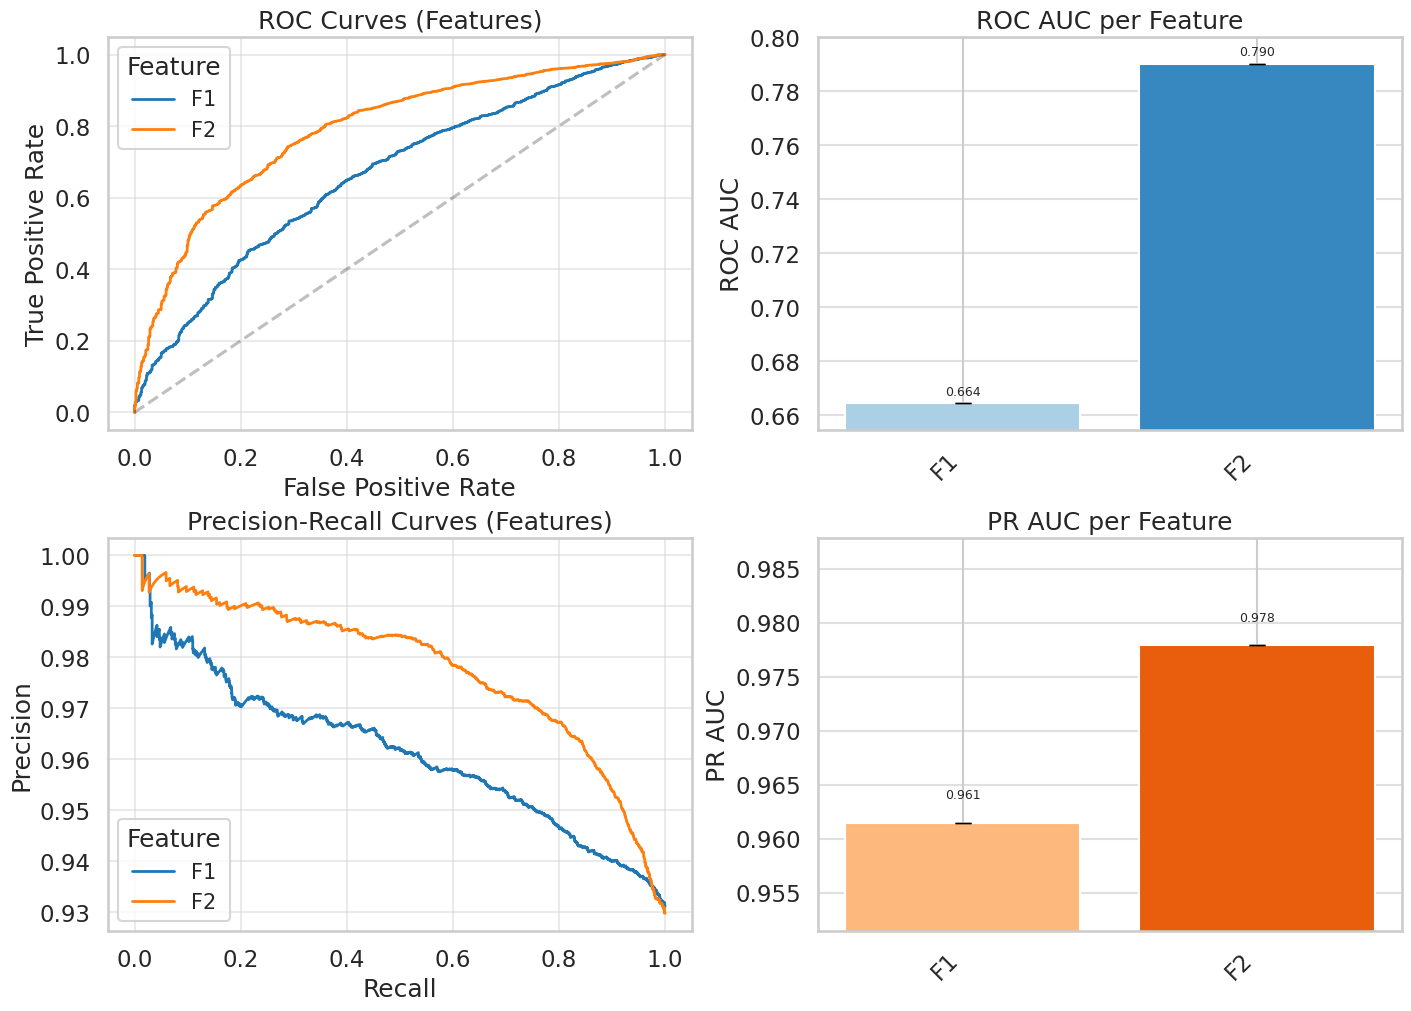

Saved feature report grid to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/report_grid_features.png
Saved feature summary CSV to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/features_summary.csv


In [10]:

# Build short codes and legend for features
feature_short_codes = {}
feature_short_desc = {}
descriptions = []
for i, r in enumerate(feature_results):
    code = f"F{i+1}"
    feature_short_codes[r['name']] = code
    desc = f"feature={r['feature']}"
    feature_short_desc[code] = desc
    descriptions.append((code, r['name'], desc))

md = "| Code | Name | Details |\n|---|---|---|\n"
for code, name, desc in descriptions:
    md += f"| **{code}** | `{name}` | {desc} |\n"

display(Markdown("### Feature Settings Legend\n\n" + md))

# Build summary DataFrame
rows = []
for r in feature_results:
    rows.append({
        'name': r['name'],
        'short': feature_short_codes.get(r['name'], r['name']),
        'feature': r['feature'],
        'ROC_AUC_mean': r.get('ROC_AUC_mean', np.nan),
        'ROC_AUC_std': r.get('ROC_AUC_std', 0.0) if r.get('ROC_AUC_std', None) is not None else 0.0,
        'PR_AUC_mean': r.get('PR_AUC_mean', np.nan),
        'PR_AUC_std': r.get('PR_AUC_std', 0.0) if r.get('PR_AUC_std', None) is not None else 0.0,
        'precision': r.get('precision'),
        'recall': r.get('recall'),
        'fpr': r.get('fpr'),
        'tpr': r.get('tpr'),
    })

feature_df = pd.DataFrame(rows)
feature_df = feature_df.sort_values('short')

# Create figure directory
fig_dir = os.path.join(os.getcwd(), 'analysis_results_figs')
os.makedirs(fig_dir, exist_ok=True)

labels = feature_df['short'].to_list()
indices = np.arange(len(labels))

# Helper from above
def compute_ylim_with_offset(means, errs=None, min_range=0.03):
    means = np.asarray(means, dtype=float)
    errs = np.zeros_like(means) if errs is None else np.asarray(errs, dtype=float)
    valid = ~np.isnan(means)
    if not valid.any():
        return 0.0, 1.0
    min_val = np.nanmin(means[valid] - errs[valid])
    max_val = np.nanmax(means[valid] + errs[valid])
    data_range = max_val - min_val
    margin = max(0.01, 0.06 * data_range)
    lower = max(0.0, min_val - margin)
    upper = min(1.0, max_val + margin)
    if (upper - lower) < min_range:
        upper = min(1.0, lower + min_range)
        lower = max(0.0, upper - min_range)
    return lower, upper

roc_means = feature_df['ROC_AUC_mean'].to_numpy(dtype=float)
roc_err = feature_df['ROC_AUC_std'].to_numpy(dtype=float)
pr_means = feature_df['PR_AUC_mean'].to_numpy(dtype=float)
pr_err = feature_df['PR_AUC_std'].to_numpy(dtype=float)

roc_low, roc_hi = compute_ylim_with_offset(roc_means, roc_err)
pr_low, pr_hi = compute_ylim_with_offset(pr_means, pr_err)

# Plot 2x2 grid for features
fig, axes = plt.subplots(2,2, figsize=(14,10), constrained_layout=True)
(ax_roc_curve, ax_roc_bar), (ax_pr_curve, ax_pr_bar) = axes

for _, row in feature_df.iterrows():
    short = row['short']
    mask = [r for r in feature_results if feature_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_roc_curve.plot(r['fpr'], r['tpr'], label=short, linewidth=2)
ax_roc_curve.plot([0,1],[0,1],'k--', alpha=0.25)
ax_roc_curve.set_title('ROC Curves (Features)')
ax_roc_curve.set_xlabel('False Positive Rate')
ax_roc_curve.set_ylabel('True Positive Rate')
ax_roc_curve.grid(alpha=0.4)
ax_roc_curve.legend(title='Feature', fontsize='small')

bars_roc = ax_roc_bar.bar(indices, roc_means, yerr=roc_err, capsize=6, color=sns.color_palette('Blues', n_colors=len(labels)))
ax_roc_bar.set_xticks(indices)
ax_roc_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_roc_bar.set_ylim(roc_low, roc_hi)
ax_roc_bar.set_title('ROC AUC per Feature')
ax_roc_bar.set_ylabel('ROC AUC')
ax_roc_bar.grid(axis='y', alpha=0.6)
for rect in bars_roc:
    h = rect.get_height()
    ax_roc_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

for _, row in feature_df.iterrows():
    short = row['short']
    mask = [r for r in feature_results if feature_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_pr_curve.plot(r['recall'], r['precision'], label=short, linewidth=2)
ax_pr_curve.set_title('Precision-Recall Curves (Features)')
ax_pr_curve.set_xlabel('Recall')
ax_pr_curve.set_ylabel('Precision')
ax_pr_curve.grid(alpha=0.4)
ax_pr_curve.legend(title='Feature', fontsize='small', loc='lower left')

bars_pr = ax_pr_bar.bar(indices, pr_means, yerr=pr_err, capsize=6, color=sns.color_palette('Oranges', n_colors=len(labels)))
ax_pr_bar.set_xticks(indices)
ax_pr_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_pr_bar.set_ylim(pr_low, pr_hi)
ax_pr_bar.set_title('PR AUC per Feature')
ax_pr_bar.set_ylabel('PR AUC')
ax_pr_bar.grid(axis='y', alpha=0.6)
for rect in bars_pr:
    h = rect.get_height()
    ax_pr_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

report_path = os.path.join(fig_dir, 'report_grid_features.png')
fig.savefig(report_path, dpi=180)
plt.show()
print(f"Saved feature report grid to: {report_path}")

# Save summary CSV
summary_csv = os.path.join(fig_dir, 'features_summary.csv')
feature_df.to_csv(summary_csv, index=False)
print(f"Saved feature summary CSV to: {summary_csv}")


- Strong learning signal by using description embedding of drugs using the GPT model.

## Analysis of trained model

- analysis of drug class
- visualizations
- 

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [96]:
import os
import warnings
import logging
import numpy as np
import pandas as pd

# Set thread limits before PyTorch import
os.environ.update({k: '1' for k in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']})
import torch


from sklearn.manifold import TSNE
from sklearn.metrics import precision_recall_curve

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType

warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")

# Setup configuration
config = Config()
config.training.seed = 42
config.graph.seed_graph_sampling = 41
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.run.upsample_negative_labels = False
config.run.use_only_sampled_negatives_in_train = False
config.graph.feature = "DESC_GPT"
config.training.repetitions = 1

# Run the model
run = main(config)

# Unpack run results
test_data, test_scores, data, model = run["test_data"], run["test_scores"], run["data"], run["model"]
node_id_map = run["node_id_map"]
reversed_node_id_map = {v: k for k, v in node_id_map.items()}

def find_balanced_threshold(y_scores):
    return float(np.median(np.asarray(y_scores).ravel()))

2026-04-20 15:25:27,536 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-04-20 15:25:30,372 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-20 15:25:30,444 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-20 15:25:30,446 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-20 15:25:30,474 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-20 15:26:02,750 - DEBUG - Early stopping at epoch 25


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7901
PR_AUC: 0.9779


In [97]:
# Compute threshold and mapped predictions
threshold = find_balanced_threshold(test_scores)
gt, pred = test_data.edge_label.cpu().numpy().astype(int), (test_scores >= threshold).astype(int)

# Fast vectorized node lookups for edges
src_idx, tgt_idx = test_data.edge_label_index.cpu().numpy()
sources, targets = np.vectorize(reversed_node_id_map.get)(src_idx), np.vectorize(reversed_node_id_map.get)(tgt_idx)

# Classification mapping
pred_classes = np.where(gt == 1, np.where(pred == 1, 'TP', 'FN'), np.where(pred == 1, 'FP', 'TN'))

# Create dataframe mapping each source and target to their prediction classes
cols = {"source": np.concatenate([sources, targets]), 
        "target": np.concatenate([targets, sources]), 
        "pred_class": np.tile(pred_classes, 2)}
edges_df = pd.DataFrame(cols)

# Aggregate classification counts across all connected edges per source
node_info_trained = pd.get_dummies(edges_df['pred_class']).groupby(edges_df['source']).sum()[['TP', 'TN', 'FP', 'FN']]
c = node_info_trained.sum(axis=1)

node_info_trained = node_info_trained.assign(
    count=c,
    perc_missclassified=(node_info_trained['FP'] + node_info_trained['FN']) / c * 100,
    perc_neg_gt=(node_info_trained['FP'] + node_info_trained['TN']) / c * 100,
    balanced_error_rate=0.5 * (
        node_info_trained['FP'] / (node_info_trained['FP'] + node_info_trained['TN'] + 1e-10) +
        node_info_trained['FN'] / (node_info_trained['TP'] + node_info_trained['FN'] + 1e-10)
    )
)

print(f"Threshold: {threshold:.4f} | Negatives: {node_info_trained['FN'].sum() + node_info_trained['TN'].sum()}")
display(node_info_trained.head())

Threshold: 0.5001 | Negatives: 10764


,TP,TN,FP,FN,count,perc_missclassified,perc_neg_gt,balanced_error_rate
source,,,,,,,,
DB00005,3,0,0,2,5,40.000000,0.000000,0.200000
DB00006,0,0,0,8,8,100.000000,0.000000,0.500000
DB00007,26,0,0,14,40,35.000000,0.000000,0.175000
DB00008,1,0,0,4,5,80.000000,0.000000,0.400000
DB00009,1,2,0,23,26,88.461538,7.692308,0.479167


### Additional Features

In [98]:
# 1. Latent Space Embeddings (t-SNE)
model.eval()
with torch.no_grad():
    node_embeddings = model.encode(data.x, data.edge_index).cpu().numpy()
    
tsne = TSNE(n_components=2)
latent_tsne = pd.DataFrame(tsne.fit_transform(node_embeddings), columns=["TSNE-1_latent", "TSNE-2_latent"])
latent_tsne.index = pd.Series(latent_tsne.index).map(lambda x: reversed_node_id_map.get(int(x), f"unknown_{int(x)}"))

# 2. Original GPT Embeddings (t-SNE)
original_df = pd.read_csv("/data/giobbi/embeddings/DESC_GPT.csv", sep="\t", index_col=0)
original_df.set_index(original_df.columns[0], inplace=True)

original_tsne = pd.DataFrame(tsne.fit_transform(original_df.select_dtypes("number").dropna()), 
                             index=original_df.index, columns=["TSNE-1_input", "TSNE-2_input"])

# 3. Load ATC Classes & Join
atc_features = pd.read_csv("/data/giobbi/embeddings/not_aligned_with_model/drug_description_enriched_atc.csv", sep="\t", index_col=0)
atc_features['atc_class_lvl_1'] = atc_features['atc_class_lvl_1'].str.split(': ').str[-1]

# Consolidate into single embedding DataFrame (Use inner join to match original behavior and drop unrelated drugs)
embedding = original_tsne.join(latent_tsne, how='inner') \
    .join(atc_features.set_index("Drug ID"), how="left") \
    .join(node_info_trained[["perc_missclassified", "balanced_error_rate", "count", "perc_neg_gt"]].rename(columns={"count": "edge_count"}), how="left")

embedding['pharma_class'], class_mapping = pd.factorize(embedding['atc_class_lvl_1'].fillna("Unknown"))
display(embedding.head(3))

,TSNE-1_input,TSNE-2_input,TSNE-1_latent,TSNE-2_latent,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,drug_name,atc_match,atc_class_lvl_1,perc_missclassified,balanced_error_rate,edge_count,perc_neg_gt
DB00005,25.850260,-42.142303,-12.219755,-33.801872,Etanercept,Dimeric fusion protein consisting of the extra...,Dimeric fusion protein consisting of the extra...,2,3,0,etanercept,Etanercept,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,40.0,0.200,5.0,0.0
DB00006,0.375309,-38.535625,19.432455,-39.822010,Bivalirudin,Bivalirudin is a synthetic 20 residue peptide ...,<DRUG> is a synthetic 20 residue peptide (<DRU...,2,4,1,bivalirudin,Bivalirudin,BLOOD AND BLOOD FORMING ORGAN DRUGS,100.0,0.500,8.0,0.0
DB00007,49.671875,46.503342,51.728455,14.104576,Leuprolide,Leuprolide is a synthetic 9-residue peptide an...,<DRUG> is a synthetic 9-residue peptide analog...,1,4,2,leuprolide,NaN,NaN,35.0,0.175,40.0,0.0


,class,n,median,IQR,mean,std
9,NERVOUS SYSTEM DRUGS,250,30.980392,45.212932,40.943854,33.091398
13,Unknown,183,100.000000,50.000000,73.803819,35.222069
2,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,176,85.714286,56.473214,72.133105,30.471861
5,CARDIOVASCULAR SYSTEM DRUGS,166,50.000000,67.428571,58.568627,30.870129
0,ALIMENTARY TRACT AND METABOLISM DRUGS,161,75.000000,65.000000,66.521739,34.661002
1,ANTIINFECTIVES FOR SYSTEMIC USE,150,100.000000,60.000000,71.994844,33.318160
11,SENSORY ORGAN DRUGS,119,65.000000,68.750000,62.055825,33.916458
10,RESPIRATORY SYSTEM DRUGS,107,31.250000,49.776786,42.713930,35.570230
6,DERMATOLOGICALS,98,70.202020,66.666667,64.399134,35.930626
7,GENITO URINARY SYSTEM AND SEX HORMONES,75,79.166667,54.444444,72.388254,29.069725


2026-04-20 15:27:40,115 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x79e28c560a90>


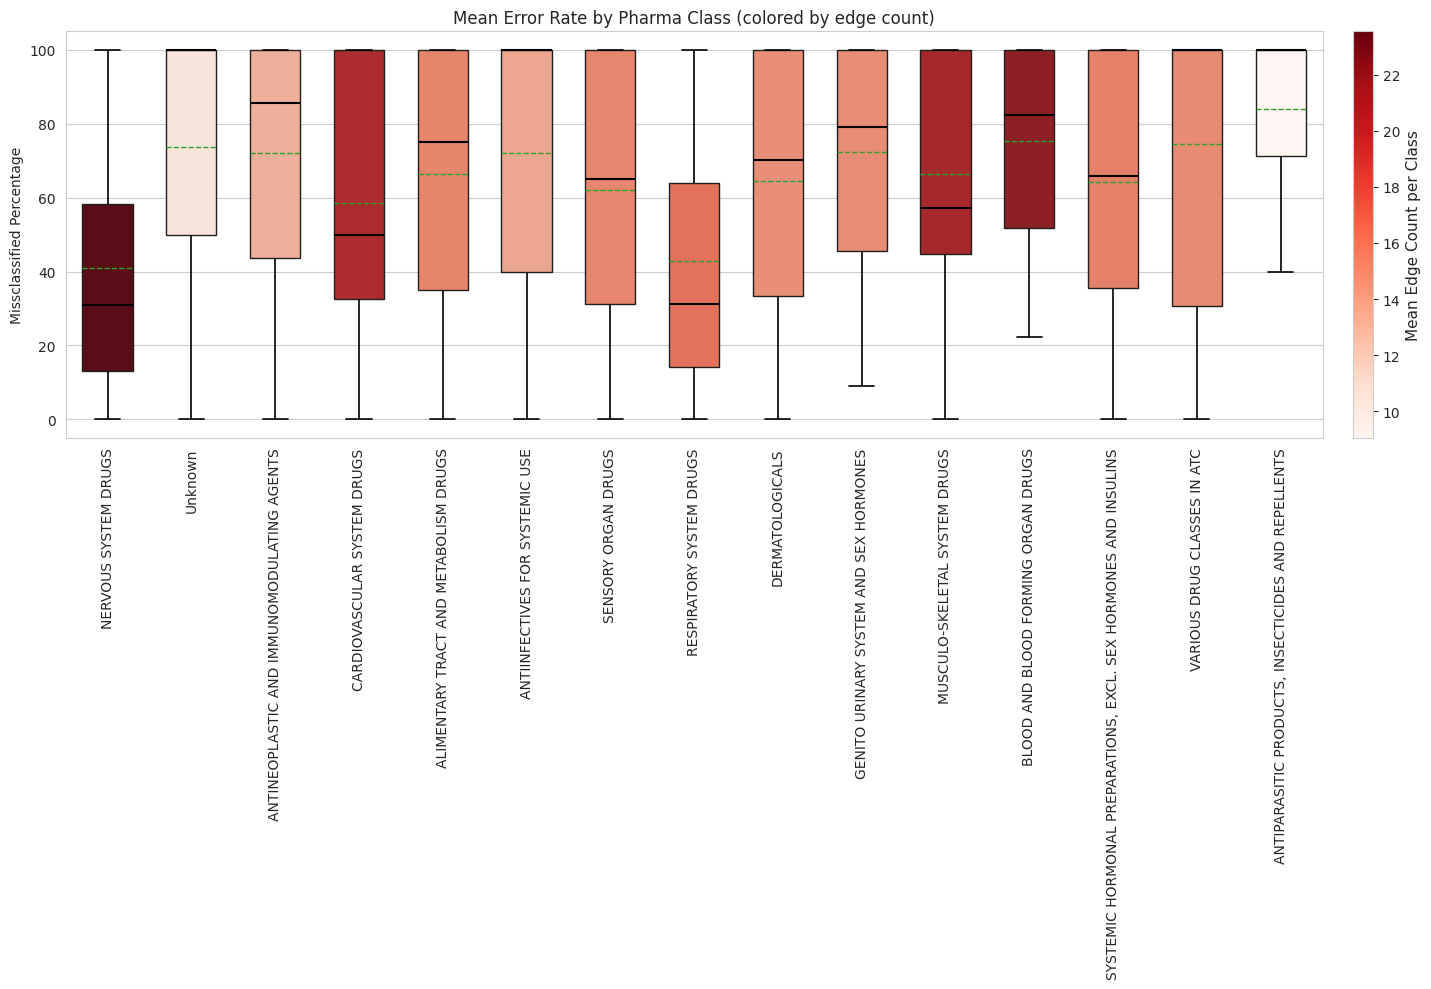

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare clean dataframe for analysis (only keep nodes with actual test predictions)
df = embedding.dropna(subset=['perc_missclassified']).reset_index(drop=True).assign(class_=lambda x: x['atc_class_lvl_1'].fillna('Unknown'))

# Generate descriptive statistics in one pass
summary_df = df.groupby('class_')['perc_missclassified'].agg(
    n='count', median='median', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25), mean='mean', std='std'
).dropna().reset_index().rename(columns={'class_': 'class'}).sort_values('n', ascending=False)

display(summary_df.head(20))
summary_df.to_csv('pharma_class_summary_all.csv', index=False)

# Visualization setup
sns.set_style('whitegrid')
order = summary_df['class'].tolist()
edge_counts = df.groupby('class_')['edge_count'].mean().reindex(order)

# Map edge counts to colors using Matplotlib's builtin normalize
norm = plt.Normalize(edge_counts.min(), edge_counts.max())
cmap = plt.cm.Reds
palette = {c: cmap(norm(v)) for c, v in edge_counts.items()}

# Create plot (increased vertical figure size to fix squishing)
fig, ax = plt.subplots(figsize=(16, 10))
sns.boxplot(
    data=df[df['class_'].isin(order)], x='class_', y='perc_missclassified', order=order,
    width=0.6, showcaps=True, showfliers=False, palette=palette, 
    showmeans=True, meanline=True, ax=ax,
    medianprops={'linewidth': 1.5, 'color': 'black'},
    whiskerprops={'linewidth': 1.2, 'color': 'black'},
    capprops={'linewidth': 1.2, 'color': 'black'},
)

ax.tick_params(axis='x', rotation=90)
ax.set(title='Mean Error Rate by Pharma Class (colored by edge count)', xlabel='', ylabel='Missclassified Percentage')

# Colorbar
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.02).set_label('Mean Edge Count per Class', fontsize=11)

plt.tight_layout()
plt.savefig('pharma_class_all_categories.png', dpi=200, bbox_inches='tight')
plt.show()

Black line: median
Green line: mean

### Pharma-class analysis — Interpretation and implications

- **Practical / scientific implications:**

  - The model's `balanced_error_rate` is heterogeneous across `atc_class_lvl_1` categories: some classes are consistently easier or harder for the model.
  - The effect size (~10%) is modest — class membership explains part of the variance but there remains substantial overlap between distributions.

- **Possible causes to investigate:**

  - Data imbalance: uneven sample counts give larger classes more training signal.
  - Domain / feature gaps: classes may differ in chemical diversity or representation in feature space.
  - Label quality: some classes may contain noisier or ambiguous labels, increasing error rates.

- **Recommended next steps (actionable):**

  - Run per‑class diagnostics: mean `balanced_error_rate`, counts, confusion matrices, and calibration plots (see `pharma_class_summary_all.csv`).
  - Try remediation experiments: stratified sampling, class reweighting, targeted augmentation, or class‑specific models.
  - Fit a regression or mixed‑effects model including sample size and covariates to quantify class effects while controlling confounders.


### Visualizations

In [102]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# ===== INTERACTIVE FILTERING =====
all_drug_ids = sorted(embedding.index.tolist())

drug_dropdown = widgets.Dropdown(
    options=[("Show all edges", None)] + [(d, d) for d in all_drug_ids],
    value=None, description="Drug ID:", layout=widgets.Layout(width='400px')
)
tsne_toggle = widgets.ToggleButtons(options=['input', 'latent'], description='t-SNE space:')

edge_label_np = test_data.edge_label.cpu().numpy()
predicted_labels_np = (test_scores >= threshold).astype(int)
edge_pairs_np = test_data.edge_label_index.cpu().t().numpy()

display(widgets.HBox([drug_dropdown, tsne_toggle]))

def create_visualization(filter_drug_id, tsne_setting_selection):
    def format_description(desc, max_length=60):
        import re
        return "<br>".join(re.findall(".{1,%d}" % max_length, desc)) if pd.notnull(desc) else ""

    tsne_suffix = f"_{tsne_setting_selection}" if tsne_setting_selection else ""
    embedding["Description_br"] = embedding["Discription"].apply(format_description)
    embedding["atc_class_lvl_1"] = embedding["atc_class_lvl_1"].fillna("Unknown")

    classes = sorted(embedding["atc_class_lvl_1"].astype(str).unique())
    unique_palette = list(dict.fromkeys(px.colors.qualitative.Set1 + px.colors.qualitative.Set2 + px.colors.qualitative.Set3))
    color_map = {cls: unique_palette[i % len(unique_palette)] for i, cls in enumerate(classes)}

    fig = go.Figure()
    for cls in classes:
        df_cls = embedding[embedding["atc_class_lvl_1"].astype(str) == cls]
        fig.add_trace(go.Scattergl(
            x=df_cls[f"TSNE-1{tsne_suffix}"], y=df_cls[f"TSNE-2{tsne_suffix}"],
            mode="markers", marker=dict(size=10, color=color_map[cls], opacity=0.8, line=dict(width=0.5, color="white")),
            text=df_cls.index.astype(str),
            customdata=df_cls[["Drug Name", "atc_class_lvl_1", "Description_br"]].values,
            hovertemplate="<b>%{customdata[0]}</b><br>Drug ID: %{text}<br>ATC Class: <b>%{customdata[1]}</b><br>t-SNE-1: %{x:.2f} | t-SNE-2: %{y:.2f}<br>Description: %{customdata[2]}<extra></extra>",
            name=cls
        ))

    rev_map = globals().get("reversed_node_id_map", {})
    def get_drug_id(n): return rev_map.get(int(n))
    def get_emb_key(n):
        for k in (n, str(n), int(n) if str(n).isdigit() else None, get_drug_id(n)):
            if k in embedding.index: return k
        return None

    is_cls = {
        "TP": (edge_label_np == 1) & (predicted_labels_np == 1),
        "FN": (edge_label_np == 1) & (predicted_labels_np == 0),
        "TN": (edge_label_np == 0) & (predicted_labels_np == 0),
        "FP": (edge_label_np == 0) & (predicted_labels_np == 1)
    }

    filter_mask = np.ones(len(edge_pairs_np), dtype=bool)
    if filter_drug_id:
        filter_mask = np.array([filter_drug_id in (get_drug_id(u), get_drug_id(v)) for u, v in edge_pairs_np])

    def add_lines(mask, color, name, dash="solid"):
        xs, ys = [], []
        for (u, v), k, p in zip(edge_pairs_np, mask, filter_mask):
            if k and p:
                ku, kv = get_emb_key(u), get_emb_key(v)
                if ku and kv:
                    x0, y0 = embedding.loc[ku, [f"TSNE-1{tsne_suffix}", f"TSNE-2{tsne_suffix}"]]
                    x1, y1 = embedding.loc[kv, [f"TSNE-1{tsne_suffix}", f"TSNE-2{tsne_suffix}"]]
                    xs.extend([x0, x1, None])
                    ys.extend([y0, y1, None])
        if xs: fig.add_trace(go.Scattergl(x=xs, y=ys, mode="lines", line=dict(color=color, width=1.5, dash=dash), name=name, hoverinfo="skip"))

    add_lines(is_cls["TP"], "rgba(0,180,0,0.6)", "TP (gt=1, pred=1)")
    add_lines(is_cls["FN"], "rgba(160,180,0,0.6)", "FN (gt=1, pred=0)", "dash")
    add_lines(is_cls["TN"], "rgba(220,20,60,0.6)", "TN (gt=0, pred=0)")
    add_lines(is_cls["FP"], "rgba(220,120,90,0.6)", "FP (gt=0, pred=1)", "dash")

    counts = {k: np.sum(v & filter_mask) for k, v in is_cls.items()}
    subtitle = f"Filter: {filter_drug_id or 'All edges'} | TP={counts['TP']}, TN={counts['TN']}, FP={counts['FP']}, FN={counts['FN']}<br>Edges represent test set interactions colored by confusion class."

    fig.update_layout(
        title=dict(text=f"t-SNE {tsne_setting_selection.capitalize()} Embedding", subtitle=dict(text=subtitle, font=dict(size=14))),
        width=1450, height=1150, plot_bgcolor="rgba(240, 242, 245, 0.5)", paper_bgcolor="white", hovermode="closest",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor="white", bordercolor="silver", borderwidth=1),
        xaxis=dict(title="t-SNE 1", showgrid=True), yaxis=dict(title="t-SNE 2", showgrid=True), margin=dict(l=80, r=20, t=140, b=80)
    )
    fig.show()

def on_filter_change(change):
    clear_output(wait=True)
    display(widgets.HBox([drug_dropdown, tsne_toggle]))
    create_visualization(drug_dropdown.value, tsne_toggle.value)

drug_dropdown.observe(on_filter_change, names='value')
tsne_toggle.observe(on_filter_change, names='value')

create_visualization("DB00007", "input")

# Discussion

# Open Points